# Static Sensor Noise Analysis — IMU & GPS
Loads rosbags recorded with sensors stationary. Computes bias, noise std dev, and GPS scatter / CEP.

In [23]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rosbags.highlevel import AnyReader
from rosbags.typesys import Stores, get_typestore

typestore = get_typestore(Stores.ROS2_HUMBLE)

DATA_DIR = Path(r"C:\Users\steff\Documents\gps_autonomous_robot\04_Data\01_Static_sensor_noise_measurement")
IMU_BAG = DATA_DIR / "IMU_rosbag2_2026_06_10-20_50_05"
GPS_BAG = DATA_DIR / "GPS_rosbag2_2026_06_10-20_30_26"

for bag in [IMU_BAG, GPS_BAG]:
    assert bag.exists(), f"Not found: {bag}"

# Print available topics in each bag
for label, bag in [("IMU", IMU_BAG), ("GPS", GPS_BAG)]:
    with AnyReader([bag], default_typestore=typestore) as r:
        topics = {c.topic for c in r.connections}
        print(f"{label} bag topics: {topics}")

IMU bag topics: {'/imu/data_raw'}
GPS bag topics: {'/gps/fix'}


In [24]:
## ── IMU ──────────────────────────────────────────────────────────────────────
rows = []
with AnyReader([IMU_BAG], default_typestore=typestore) as reader:
    connections = [c for c in reader.connections if c.topic == '/imu/data_raw']
    t_start = None
    for connection, timestamp, rawdata in reader.messages(connections=connections):
        if t_start is None:
            t_start = timestamp
        if (timestamp - t_start) / 1e9 < 5.0:   # skip first 5 s
            continue
        msg = reader.deserialize(rawdata, connection.msgtype)
        rows.append({
            't_ns': timestamp,
            'ax': msg.linear_acceleration.x,
            'ay': msg.linear_acceleration.y,
            'az': msg.linear_acceleration.z,
            'gx': msg.angular_velocity.x,
            'gy': msg.angular_velocity.y,
            'gz': msg.angular_velocity.z,
        })

assert rows, "No /imu/data_raw messages found — check topic name above"
imu = pd.DataFrame(rows)
imu['t_s'] = (imu['t_ns'] - imu['t_ns'].iloc[0]) / 1e9
print(f"IMU  — Samples: {len(imu)}  Duration: {imu['t_s'].iloc[-1]:.1f} s  Rate: {len(imu)/imu['t_s'].iloc[-1]:.1f} Hz")

IMU  — Samples: 8438  Duration: 84.4 s  Rate: 100.0 Hz


In [25]:
imu_stats = pd.DataFrame({
    'Bias (mean)': imu[['ax','ay','az','gx','gy','gz']].mean(),
    'Std dev':     imu[['ax','ay','az','gx','gy','gz']].std(),
    'Min':         imu[['ax','ay','az','gx','gy','gz']].min(),
    'Max':         imu[['ax','ay','az','gx','gy','gz']].max(),
})
imu_stats.index = ['Accel X [m/s²]','Accel Y [m/s²]','Accel Z [m/s²]',
                   'Gyro X [rad/s]', 'Gyro Y [rad/s]', 'Gyro Z [rad/s]']
print("=== IMU Noise Statistics ===")
print(imu_stats.to_string(float_format='{:.5f}'.format))

=== IMU Noise Statistics ===
                Bias (mean)  Std dev      Min      Max
Accel X [m/s²]     -0.19263  0.02087 -0.27303 -0.11257
Accel Y [m/s²]     -0.09225  0.02382 -0.17484 -0.01198
Accel Z [m/s²]      9.65386  0.02014  9.57289  9.73336
Gyro X [rad/s]     -0.02091  0.00198 -0.02825 -0.01332
Gyro Y [rad/s]      0.10451  0.00160  0.09646  0.11085
Gyro Z [rad/s]      0.00419  0.00148 -0.00293  0.01066


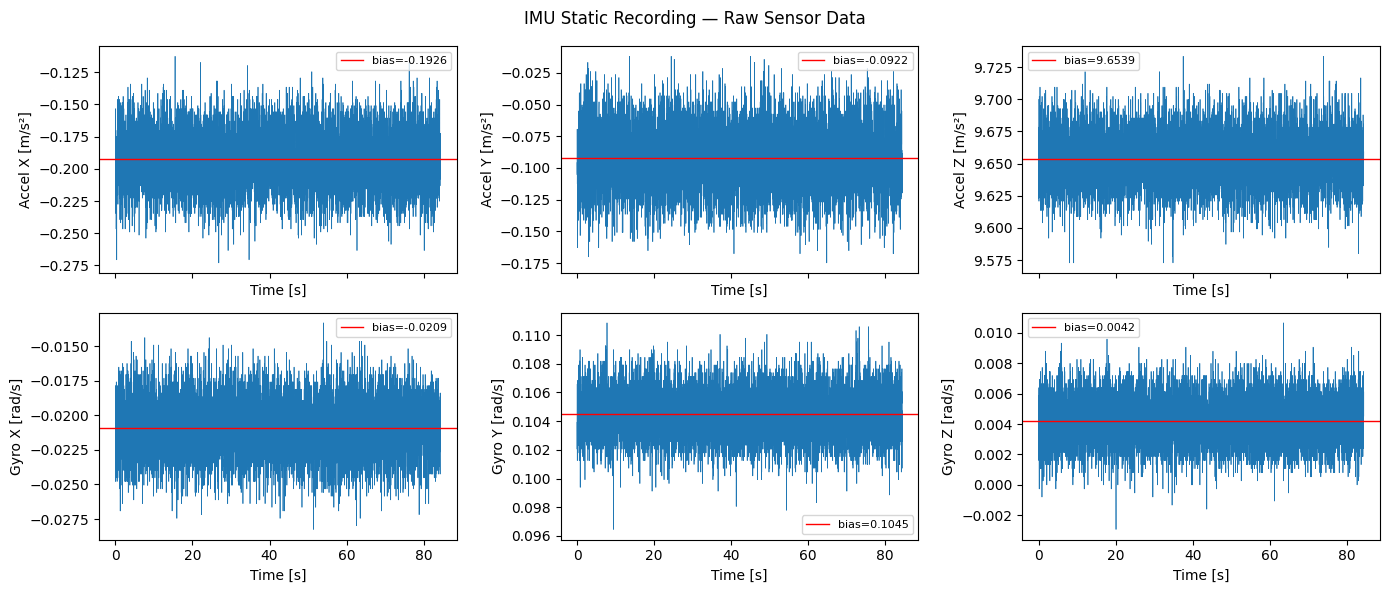

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(14, 6), sharex=True)
fig.suptitle("IMU Static Recording — Raw Sensor Data")

channels = [
    ('ax', 'Accel X [m/s²]'), ('ay', 'Accel Y [m/s²]'), ('az', 'Accel Z [m/s²]'),
    ('gx', 'Gyro X [rad/s]'), ('gy', 'Gyro Y [rad/s]'), ('gz', 'Gyro Z [rad/s]'),
]
for ax, (col, label) in zip(axes.flat, channels):
    ax.plot(imu['t_s'], imu[col], linewidth=0.5)
    ax.axhline(imu[col].mean(), color='r', linewidth=1, label=f'bias={imu[col].mean():.4f}')
    ax.set_ylabel(label)
    ax.set_xlabel('Time [s]')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('imu_static_timeseries.png', dpi=150)
plt.show()

In [27]:
## ── GPS ──────────────────────────────────────────────────────────────────────
rows = []
with AnyReader([GPS_BAG], default_typestore=typestore) as reader:
    connections = [c for c in reader.connections if c.topic == '/gps/fix']
    for connection, timestamp, rawdata in reader.messages(connections=connections):
        msg = reader.deserialize(rawdata, connection.msgtype)
        if msg.status.status < 0:   # skip no-fix messages
            continue
        rows.append({
            't_ns':  timestamp,
            'lat':   msg.latitude,
            'lon':   msg.longitude,
            'alt':   msg.altitude,
        })

assert rows, "No valid /gps/fix messages found — check topic name above"
gps = pd.DataFrame(rows)
gps['t_s'] = (gps['t_ns'] - gps['t_ns'].iloc[0]) / 1e9
print(f"GPS  — Samples: {len(gps)}  Duration: {gps['t_s'].iloc[-1]:.1f} s  Rate: {len(gps)/gps['t_s'].iloc[-1]:.2f} Hz")

GPS  — Samples: 345  Duration: 344.0 s  Rate: 1.00 Hz


In [28]:
# Convert lat/lon scatter to metres (relative to mean position)
lat0, lon0 = gps['lat'].mean(), gps['lon'].mean()
M_PER_DEG_LAT = 111_111.0
M_PER_DEG_LON = 111_111.0 * np.cos(np.radians(lat0))        # Correct longitude with cosine of latitude

gps['dy_m'] = (gps['lat'] - lat0) * M_PER_DEG_LAT
gps['dx_m'] = (gps['lon'] - lon0) * M_PER_DEG_LON
gps['r_m']  = np.sqrt(gps['dx_m']**2 + gps['dy_m']**2)

cep50 = np.percentile(gps['r_m'], 50)
cep95 = np.percentile(gps['r_m'], 95)

print("=== GPS Static Accuracy ===")
print(f"  Mean lat : {lat0:.7f} °")
print(f"  Mean lon : {lon0:.7f} °")
print(f"  Std lat  : {gps['dy_m'].std():.3f} m")
print(f"  Std lon  : {gps['dx_m'].std():.3f} m")
print(f"  CEP50    : {cep50:.2f} m   (50 % of fixes within this radius)")
print(f"  CEP95    : {cep95:.2f} m   (95 % of fixes within this radius)")

=== GPS Static Accuracy ===
  Mean lat : 28.1500862 °
  Mean lon : -81.8508914 °
  Std lat  : 1.599 m
  Std lon  : 1.255 m
  CEP50    : 1.84 m   (50 % of fixes within this radius)
  CEP95    : 3.49 m   (95 % of fixes within this radius)


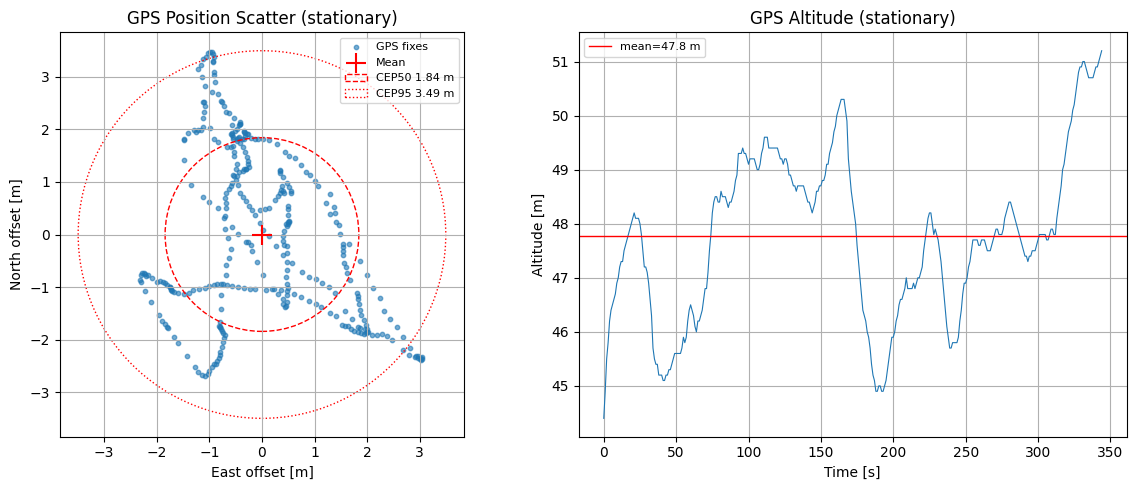

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: 2-D position scatter
ax = axes[0]
ax.scatter(gps['dx_m'], gps['dy_m'], s=10, alpha=0.6, label='GPS fixes')
ax.scatter(0, 0, marker='+', s=200, color='red', zorder=5, label='Mean')
for r, ls, lbl in [(cep50, '--', f'CEP50 {cep50:.2f} m'), (cep95, ':', f'CEP95 {cep95:.2f} m')]:
    circle = plt.Circle((0, 0), r, fill=False, linestyle=ls, color='red', label=lbl)
    ax.add_patch(circle)
ax.set_aspect('equal')
ax.set_xlabel('East offset [m]')
ax.set_ylabel('North offset [m]')
ax.set_title('GPS Position Scatter (stationary)')
ax.legend(fontsize=8)
ax.grid(True)

# Right: altitude time series
ax = axes[1]
ax.plot(gps['t_s'], gps['alt'], linewidth=0.8)
ax.axhline(gps['alt'].mean(), color='r', linewidth=1, label=f'mean={gps["alt"].mean():.1f} m')
ax.set_xlabel('Time [s]')
ax.set_ylabel('Altitude [m]')
ax.set_title('GPS Altitude (stationary)')
ax.legend(fontsize=8)
ax.grid(True)

plt.tight_layout()
plt.savefig('gps_static_scatter.png', dpi=150)
plt.show()